In [1]:
import os 

In [2]:
for dirpath,dirnames,filenames in os.walk(r'D:\tensorflow\10_food_classes_10_percent'):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

There are 2 directories and 0 images in D:\tensorflow\10_food_classes_10_percent
There are 10 directories and 0 images in D:\tensorflow\10_food_classes_10_percent\test
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\chicken_curry
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\chicken_wings
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\fried_rice
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\grilled_salmon
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\hamburger
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\ice_cream
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\pizza
There are 0 directories and 250 images in D:\tensorflow\10_food_classes_10_percent\test\ramen
There are 0 directories and 250 images in 

In [3]:
import tensorflow as tf 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
BATCH_SIZE = 32
IMAGE_SIZE=(224,224)

train_dir = r'D:\tensorflow\10_food_classes_10_percent\train'
test_dir  = r'D:\tensorflow\10_food_classes_10_percent\test'

train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

print("Training_images:")

train_data_10_percent = train_datagen.flow_from_directory(train_dir,
                                                          batch_size=BATCH_SIZE,
                                                          target_size=IMAGE_SIZE,
                                                          class_mode = 'categorical')
print("Testing_images")
test_data = test_datagen.flow_from_directory(test_dir,
                                              target_size=IMAGE_SIZE,
                                              batch_size=BATCH_SIZE,
                                              class_mode = 'categorical')

Training_images:
Found 750 images belonging to 10 classes.
Testing_images
Found 2500 images belonging to 10 classes.


In [5]:
# Create tensorboard callback (functionized because need to create a new one for each model)
import datetime
def create_tensorboard_callback(dir_name, experiment_name):
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(
      log_dir=log_dir
  )
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback

In [6]:
import tensorflow_hub as hub
from tensorflow.keras import layers

c:\Users\venka\anaconda3\envs\tf\lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [7]:
def create_model(model_url, num_classes=10):

    feature_extraction_layer = hub.KerasLayer(
        model_url,
        trainable=False,
        name="feature_extraction_layer",
        input_shape=IMAGE_SIZE + (3,)
    )

    model = tf.keras.Sequential([
        feature_extraction_layer,
        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            name="output_layer"
        )
    ])

    return model

In [8]:
import sys

print("Python:", sys.executable)

try:
    import PIL
    print("Pillow:", PIL.__version__)
    from PIL import Image
    print("PIL.Image: OK")
except Exception as e:
    print("PIL ERROR:", e)

Python: c:\Users\venka\anaconda3\envs\tf\python.exe
Pillow: 11.3.0
PIL.Image: OK


In [9]:
import tensorflow as tf
import keras

import tensorflow_hub as hub

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("TensorFlow Hub:", hub.__version__)

TensorFlow: 2.10.0
Keras: 2.10.0
TensorFlow Hub: 0.16.1


In [10]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf

import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt


print("TensorFlow Hub:", hub.__version__)

TensorFlow Hub: 0.16.1


In [11]:
from PIL import Image

print("Pillow:", Image.__version__)

Pillow: 11.3.0


In [12]:
import datetime
import os

def create_tensorboard_callback(dir_name, experiment_name):
    log_dir = os.path.join(
        dir_name,
        experiment_name,
        datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    )

    return tf.keras.callbacks.TensorBoard(log_dir=log_dir)

In [13]:
def create_model(model_url, num_classes=10):

    feature_extraction_layer = hub.KerasLayer(
        model_url,
        trainable=False,
        name="feature_extraction_layer",
        input_shape=IMAGE_SIZE + (3,)
    )

    model = tf.keras.Sequential([
        feature_extraction_layer,
        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            name="output_layer"
        )
    ])

    return model

In [14]:
resnet50_model = create_model(
    "https://www.kaggle.com/models/tensorflow/resnet-50/TensorFlow2/classification/1",
    num_classes=train_data_10_percent.num_classes
)

In [15]:
resnet50_model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

In [16]:
resnet50_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 feature_extraction_layer (K  (None, 1001)             25612201  
 erasLayer)                                                      
                                                                 
 output_layer (Dense)        (None, 10)                10020     
                                                                 
Total params: 25,622,221
Trainable params: 10,020
Non-trainable params: 25,612,201
_________________________________________________________________


In [17]:
import tensorboard
print(tensorboard.__version__)

2.10.1


In [18]:
resnet50_history = resnet50_model.fit(
    train_data_10_percent,
    epochs=5,
    steps_per_epoch=len(train_data_10_percent),
    validation_data=test_data,
    validation_steps=len(test_data),
    callbacks=[
        create_tensorboard_callback(
            dir_name="tensorflow_hub",
            experiment_name="resnet50"
        )
    ]
)

Epoch 1/5
24/24 [==============================] - 23s 611ms/step - loss: 2.3024 - accuracy: 0.1040 - val_loss: 2.2936 - val_accuracy: 0.1460
Epoch 2/5
24/24 [==============================] - 13s 570ms/step - loss: 2.2854 - accuracy: 0.3040 - val_loss: 2.2765 - val_accuracy: 0.3992
Epoch 3/5
24/24 [==============================] - 14s 596ms/step - loss: 2.2692 - accuracy: 0.4293 - val_loss: 2.2595 - val_accuracy: 0.4692
Epoch 4/5
24/24 [==============================] - 14s 599ms/step - loss: 2.2530 - accuracy: 0.4920 - val_loss: 2.2428 - val_accuracy: 0.5616
Epoch 5/5
24/24 [==============================] - 14s 599ms/step - loss: 2.2367 - accuracy: 0.5600 - val_loss: 2.2266 - val_accuracy: 0.5832


In [19]:
# If you wanted to, you could really turn this into a helper function to load in with a helper.py script...
import matplotlib.pyplot as plt

# Plot the validation and training data separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """ 
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

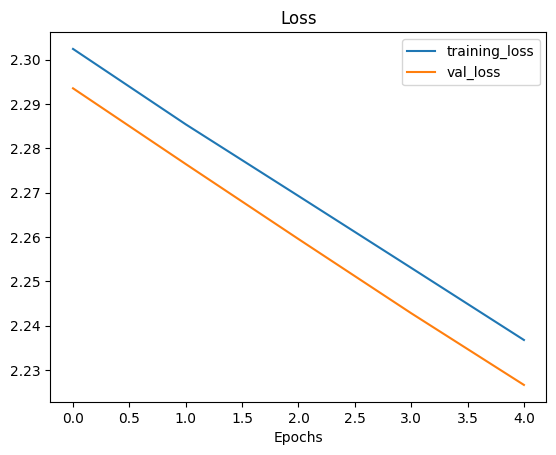

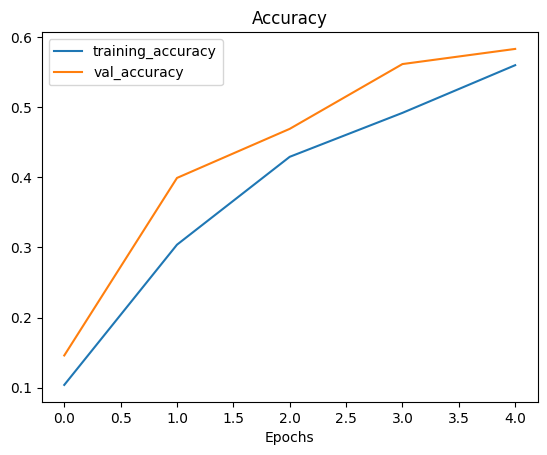

In [20]:
plot_loss_curves(resnet50_history)

In [21]:
resnet50_history_1 = resnet50_model.fit(
    train_data_10_percent,
    epochs=10,
    steps_per_epoch=len(train_data_10_percent),
    validation_data=test_data,
    validation_steps=len(test_data),
    callbacks=[
        create_tensorboard_callback(
            dir_name="tensorflow_hub",
            experiment_name="resnet50"
        )
    ]
)

Epoch 1/10
24/24 [==============================] - 15s 608ms/step - loss: 2.2211 - accuracy: 0.5813 - val_loss: 2.2102 - val_accuracy: 0.5928
Epoch 2/10
24/24 [==============================] - 14s 604ms/step - loss: 2.2055 - accuracy: 0.5947 - val_loss: 2.1939 - val_accuracy: 0.6036
Epoch 3/10
24/24 [==============================] - 14s 612ms/step - loss: 2.1896 - accuracy: 0.6053 - val_loss: 2.1783 - val_accuracy: 0.6096
Epoch 4/10
24/24 [==============================] - 14s 619ms/step - loss: 2.1745 - accuracy: 0.6200 - val_loss: 2.1625 - val_accuracy: 0.6200
Epoch 5/10
24/24 [==============================] - 14s 613ms/step - loss: 2.1594 - accuracy: 0.6253 - val_loss: 2.1470 - val_accuracy: 0.6292
Epoch 6/10
24/24 [==============================] - 15s 624ms/step - loss: 2.1445 - accuracy: 0.6253 - val_loss: 2.1316 - val_accuracy: 0.6316
Epoch 7/10
24/24 [==============================] - 15s 623ms/step - loss: 2.1297 - accuracy: 0.6280 - val_loss: 2.1167 - val_accuracy: 0.6288

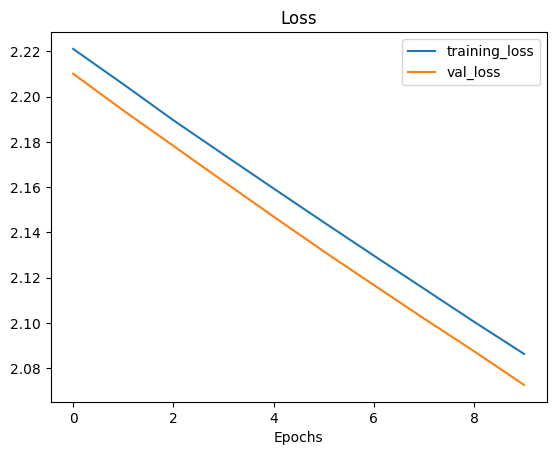

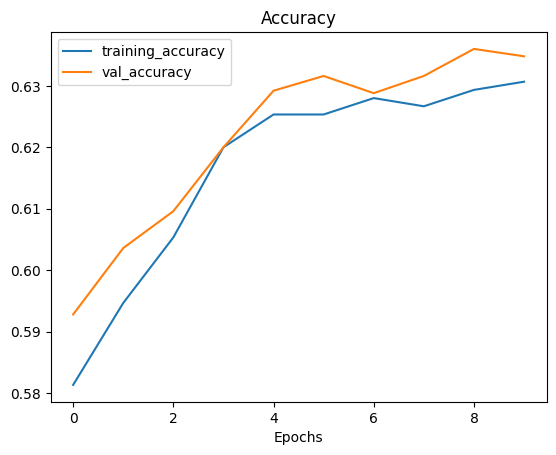

In [22]:
plot_loss_curves(resnet50_history_1)